# What cloud types are actually in ERA5 over the North Slope?

An exploratory pass over the ERA5 **pressure-level** archive that asks what
vertical cloud structures are there and how often, rather than checking whether
the profiles match structures chosen in advance.

The three free attributes are the ones you named: **phase**, **vertical
arrangement**, and **number of layers**. What this notebook adds is that the
combinations are not enumerated by hand.

## The method, and why not the obvious one

The methodical route -- step through every hour, decide the three attributes,
look for patterns afterwards -- is right in spirit. Two things go wrong in
practice.

**Writing the decision tree by hand pre-decides the answer.** You find the
structures you thought to write down and stay blind to the rest, so the
frequencies come back as a property of your imagination as much as of the
atmosphere. Rachel's A-F does this deliberately and correctly, because she was
testing six specific radiative configurations. Asking *what is out there* is a
different question and wants a different tool.

**Done naively it is also slow.** The archive is 120 files x 48 hours x 41 x 61
cells, **14 million columns**. A Python loop building a tuple per column takes
tens of minutes, and every parameter you want to change costs another run.

Both problems have one fix. Each column is reduced to a short **signature** --
its layers, bottom to top, each tagged with phase, altitude regime and internal
arrangement -- and that signature is packed into a single `int64`. Finding the
common types is then `np.unique(codes, return_counts=True)`. The *alphabet* is
fixed and known; which **words** occur, and how often, is measured. The whole
archive is one vectorised streaming pass (~2 min for 120 files), and only
counters survive it, so memory scales with the number of distinct signatures,
not columns.

A signature reads bottom-layer-first:

| signature | means |
|---|---|
| `BL:M^L` | one boundary-layer mixed-phase layer, **liquid-topped** |
| `BL:L \| MID:I` | liquid deck near the surface, separate ice layer at 3-6 km |
| `LOW:I \| HIGH:I` | two ice layers, one at 1-3 km and one above 6 km |

with phase `L`/`M`/`I` from the layer's ice **mass** fraction, regime from the
layer base height (`BL` <1 km, `LOW` 1-3, `MID` 3-6, `HIGH` 6 km-tropopause,
`TP+` above it), and `^L`/`^I` marking a layer whose top level is more liquid
(or more ice) than its bottom.

The same pass also keeps a stratified sample of raw profiles, so the symbolic
taxonomy can be **cross-checked against unsupervised clustering** at the end --
the honest way to ask whether the alphabet is finding real modes or imposing
them.

## Two things about the archive, up front

**The level axis runs top-down as ERA5 stores it.** `cloud_vertical_cases.py`
documents bottom-up and does not hold it, which silently inverts every
"liquid-topped" test in the ported A-F cases. This notebook's module asserts the
direction at run time instead (`_check_bottom_up`).

**107 of the 120 pressure files have no `z`.** Only the first 13 (1-26 Aug
2025) were downloaded with the extended variable set. Heights here are therefore
integrated hydrostatically from `t` and `q`; those 13 files are used to check the
derivation, in the validation section below.


## Setup


In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import cloud_type_discovery as ctd

warnings.filterwarnings("ignore", category=FutureWarning)
plt.rcParams["figure.dpi"] = 110      # on-screen only; saved files use dpi=
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 40)

SAVE_DIR = Path("figures/cloud_types")
SAVE_DIR.mkdir(parents=True, exist_ok=True)


## Inputs

Everything that decides what gets read and how a layer is defined. Changing any
of these means re-running the load cell; nothing else does.

The three that actually move the answer, in order:

- **`CONTENT_THRESHOLD`** decides what counts as cloud at all. `1e-3` g m$^{-3}$
  is near a cloud radar's detection floor.
- **`MIN_GAP_M`** decides the layer count. At 25 hPa spacing one sub-threshold
  level is ~200 m near the ground, and calling that a clear gap turns one deck
  into two. 500 m merges single-level gaps low down but not aloft.
- **`MIN_LAYER_PATH`** drops numerical traces. The 5th percentile of layer
  condensate path is 0.5-1.3 g m$^{-2}$, so 1.0 trims noise, not clouds.

All three are swept at the end. `STRIDE` thins the grid -- neighbouring 0.25°
cells are strongly correlated, so a stride of 4 costs little and checks the
ranking is not an artefact of counting the same weather many times.


In [2]:
REGION            = "barrow"
STORAGE           = "local"
MAX_FILES         = 0          # 0 = the whole pressure archive (120 files, ~2 min)
STRIDE            = 1          # take every Nth grid cell in lat and lon

CONTENT_THRESHOLD = 1e-3       # g m-3, above which a level holds that phase
CONTENT_BASIS     = "gridmean" # or "incloud": divide by cloud fraction first
MIN_GAP_M         = 500.0      # thinner clear slabs do not split a layer
MIN_LAYER_PATH    = 1.0        # g m-2; layers below this are dropped
LIQ_MAX, ICE_MIN  = 0.1, 0.9   # f_ice cuts for L / M / I
REGIME_EDGES_M    = (1000.0, 3000.0, 6000.0)
MAX_LAYERS        = 5

CACHE = SAVE_DIR / "analysis_default.npz"
RECOMPUTE = False              # True forces a fresh pass; a stale cache is
                               # detected and recomputed automatically anyway


## Load the data

The slow cell, and the only one that touches the archive. Cached to an `.npz`,
so a second run of the notebook is instant.

**The cache checks itself.** The download is incremental -- this analysis was
first built when 63 files were on disk and the directory held 120 a week later
-- so the cache records the names and sizes of the files it was built from, and
`cache_status` compares them against what is there now. A grown archive
recomputes on its own; you do not have to remember `RECOMPUTE`.


In [3]:
A = None
if CACHE.exists() and not RECOMPUTE:
    A = ctd.load_analysis(CACHE)
    stale, why = ctd.cache_status(A, region=REGION, storage=STORAGE,
                                  max_files=MAX_FILES)
    print(f"  {why}")
    if stale:
        A = None
    else:
        print(f"loaded cached analysis: {A.n_files} files, months {A.months}")

if A is None:
    A = ctd.prepare(
        argv=["--region", REGION, "--storage", STORAGE],
        max_files=MAX_FILES, stride=STRIDE,
        content_threshold=CONTENT_THRESHOLD, content_basis=CONTENT_BASIS,
        min_gap_m=MIN_GAP_M, min_layer_path=MIN_LAYER_PATH,
        liq_max=LIQ_MAX, ice_min=ICE_MIN,
        regime_edges=list(REGIME_EDGES_M), max_layers=MAX_LAYERS,
    )
    ctd.save_analysis(A, CACHE)
    print(f"\ncached -> {CACHE}")


  cache is current: 120 file(s)
loaded cached analysis: 120 files, months [1, 2, 3, 8, 9, 10, 11, 12]


## Validate before interpreting

Two things are derived rather than read, and both are checkable.

**Heights.** 107 of 120 files have no `z`, so layer bases and tops come from
hydrostatic integration of `t` and `q`. The 13 that do carry `z` test it.

A note on the test itself: the obvious check -- compare level-to-level
thicknesses -- is *invalid* wherever the level spacing changes, and this archive
changes it twice (25 → 50 hPa at 750, 50 → 25 hPa at 250). Each level owns the
slab between the midpoints to its neighbours, so at a spacing change that slab is
asymmetric. The pairwise error at those two joins is +67/−67 m and −156/+165 m:
equal and opposite, cancelling exactly, because the slabs are right and the
*statistic* is wrong. The cumulative height -- which is what a layer base
actually is -- is the fair test.


In [4]:
import glob, xarray as xr

# One of the 13 files that carries geopotential, with real surface pressure.
f_z = "data/barrow_pressure/era5_pl_barrow_202508_01-02.nc"
with xr.open_dataset(f_z) as _pl:
    _dims = [d for d in _pl["t"].dims if d != "pressure_level"]
    _sp = (xr.open_dataset("data/barrow/era5_seb_barrow_202508_01-11.nc")["sp"]
           .sel(valid_time=_pl.valid_time.values).load()
           .transpose(*_dims).values.reshape(-1))

st = ctd.validate_heights(f_z, sp_da=_sp)
print(f"hydrostatic height vs ERA5 geopotential, {st['n_columns']:,} columns, "
      f"measured from {st['ref_hpa']:.0f} hPa\n")
for hpa in (850.0, 700.0, 500.0, 300.0, 200.0):
    d = st["per_span"][hpa]
    print(f"   up to {hpa:4.0f} hPa   mean {d['mean_error_m']:+7.2f} m   "
          f"rms {d['rms_error_m']:6.2f} m   ({d['mean_error_pct']:+.3f} %)")
print("\n-> 0.02% through the lower troposphere, where nearly all the cloud is.")


hydrostatic height vs ERA5 geopotential, 120,048 columns, measured from 975 hPa

   up to  850 hPa   mean   +0.01 m   rms   0.39 m   (+0.001 %)
   up to  700 hPa   mean   +0.48 m   rms   0.64 m   (+0.018 %)
   up to  500 hPa   mean   +2.50 m   rms   2.54 m   (+0.047 %)
   up to  300 hPa   mean   +9.83 m   rms   9.89 m   (+0.110 %)
   up to  200 hPa   mean  +21.47 m   rms  21.58 m   (+0.186 %)

-> 0.02% through the lower troposphere, where nearly all the cloud is.


**The cloud mask.** ERA5 publishes its own low / medium / high cloud cover
(`lcc`/`mcc`/`hcc`, split at 800 and 450 hPa). Applying the same split to this
decomposition gives a like-for-like test of the condensate threshold.

They will not agree exactly and should not: `lcc` is a maximum-random overlap of
model-level cloud *fraction*, not a condensate threshold. A large **one-sided**
bias is the thing to watch for.


  saved figures/cloud_types/cloud_types_era5_check.png
  low     agree  83.1%   condensate only   5.8%   ERA5 cover only  11.1%
  medium  agree  89.4%   condensate only   8.7%   ERA5 cover only   1.8%
  high    agree  92.1%   condensate only   0.7%   ERA5 cover only   7.2%


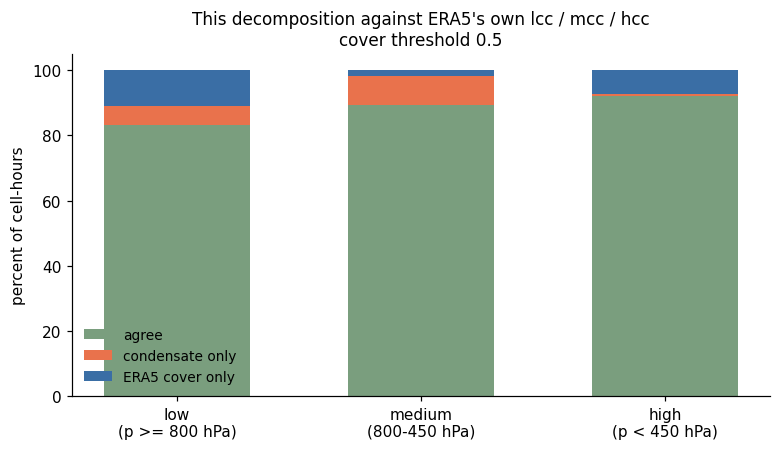

In [5]:
fig = ctd.fig_era5_check(A, out_dir=SAVE_DIR)
for b, name in enumerate(("low", "medium", "high")):
    t = A.era5_band[b]; tot = t.sum()
    print(f"  {name:<7} agree {100*(t[0,0]+t[1,1])/tot:5.1f}%   "
          f"condensate only {100*t[1,0]/tot:5.1f}%   "
          f"ERA5 cover only {100*t[0,1]/tot:5.1f}%")


## Question 1 — how many layers?

Read the caveat with the number: **vertical resolution sets the layer count.**
The 23 pressure levels are ~200 m apart below 700 hPa and ~700-1000 m apart
above 500 hPa, while Arctic boundary-layer stratus is often 200-400 m thick. A
real cloud can occupy one level and two stacked decks can merge into one, so
these counts are a **lower bound**, and the bound is tighter aloft.


  saved figures/cloud_types/cloud_types_layer_count.png
  cloudy fraction: 83.2% of all cell-hours (domain), 84.8% (Utqiagvik cell)

    1 layer(s):  74.20%  domain    69.44%  Utqiagvik
    2 layer(s):  23.40%  domain    27.77%  Utqiagvik
    3 layer(s):   2.31%  domain     2.73%  Utqiagvik
    4 layer(s):   0.08%  domain     0.06%  Utqiagvik
   5+ layer(s):   0.00%  domain     0.00%  Utqiagvik

  single or double: 97.6% of cloudy hours


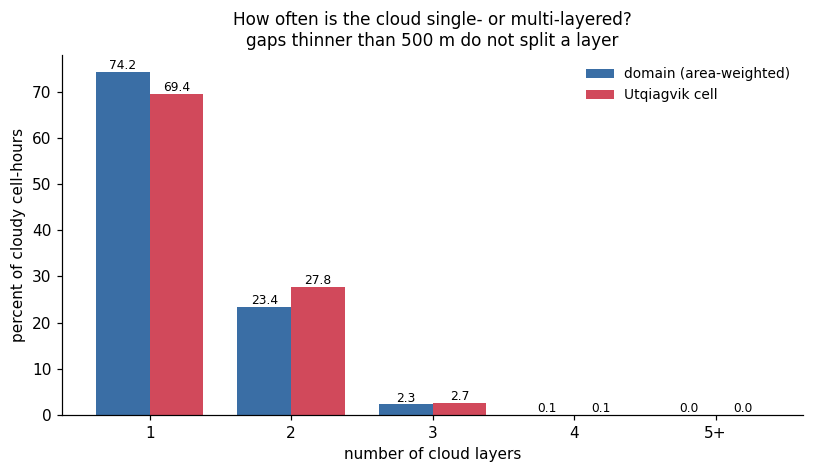

In [6]:
fig = ctd.fig_layer_count(A, out_dir=SAVE_DIR)

dom = ctd.layer_count_percent(A, 0)
site = ctd.layer_count_percent(A, 1)
print(f"  cloudy fraction: {100*A.cloudy_w[0]/A.total_w[0]:.1f}% of all cell-hours "
      f"(domain), {100*A.cloudy_w[1]/A.total_w[1]:.1f}% (Utqiagvik cell)\n")
for i, (d, s) in enumerate(zip(dom, site)):
    tag = f"{i+1}" + ("+" if i == len(dom) - 1 else "")
    print(f"  {tag:>3} layer(s): {d:6.2f}%  domain   {s:6.2f}%  Utqiagvik")
print(f"\n  single or double: {dom[0]+dom[1]:.1f}% of cloudy hours")


## Question 2 — where are they vertically?

Two different readings, both shown below, and they answer different questions:

- the **heat map** places each layer by its *base* -- "what kind of layer is
  this?"
- the **bars** count a column if any layer's vertical *span* reaches into the
  band -- "is there cloud in the boundary layer right now?"

`TP+` (above the diagnosed lapse-rate tropopause) is a **lower bound**: the
archive stops at 200 hPa (~11.8 km). The Arctic tropopause sits near 250-300 hPa
in winter so some above-tropopause layers are visible, but anything higher is
not, and ERA5 does not represent polar stratospheric clouds in any case.

`BL` is a **height band**, not a diagnosed boundary layer. The single-level
archive has no `blh`, and a boundary-layer top diagnosed from a profile sampled
every ~200 m is not meaningful in an Arctic winter inversion. `BL` means "base
below 1 km above ground", nothing more.


  saved figures/cloud_types/cloud_types_regime_phase.png
  cloud present in each band, percent of ALL cell-hours (by span):

     BL  boundary layer (<1 km)      75.39%  domain    75.72%  Utqiagvik
    LOW  low (1-3 km)                58.89%  domain    62.15%  Utqiagvik
    MID  mid (3-6 km)                36.61%  domain    39.46%  Utqiagvik
   HIGH  high (6 km-tropopause)      22.51%  domain    25.30%  Utqiagvik
    TP+  above tropopause             1.01%  domain     1.45%  Utqiagvik

  tropopause diagnosed in 71.2% of columns; the rest cannot separate HIGH from TP+.


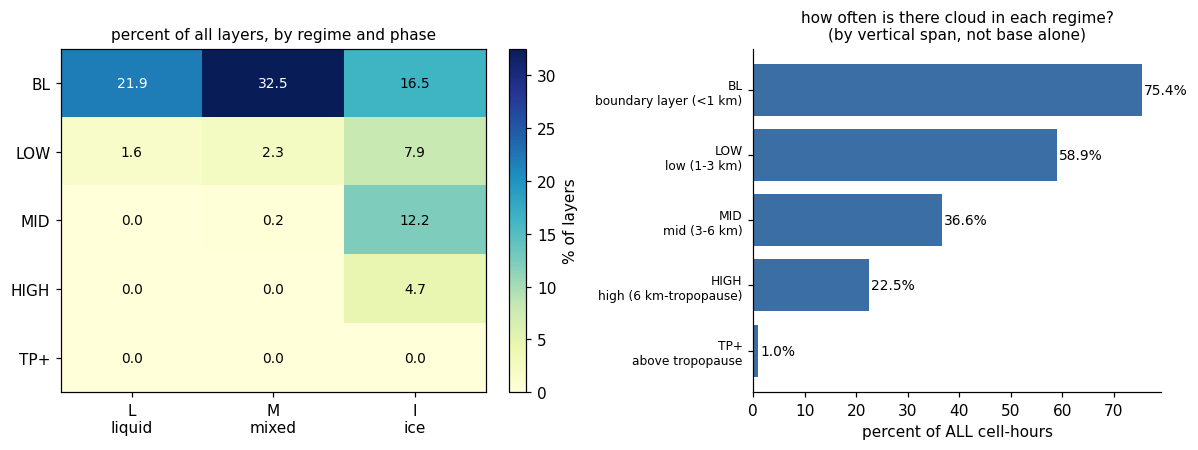

In [7]:
fig = ctd.fig_regime_phase(A, out_dir=SAVE_DIR)

print("  cloud present in each band, percent of ALL cell-hours (by span):\n")
for r in range(ctd.N_REGIME):
    d = 100*A.regime_presence_w[0, r]/A.total_w[0]
    s = 100*A.regime_presence_w[1, r]/A.total_w[1]
    print(f"  {ctd.REGIME_SYM[r]:>5}  {ctd.REGIME_NAME[r]:<26} "
          f"{d:6.2f}%  domain   {s:6.2f}%  Utqiagvik")
print(f"\n  tropopause diagnosed in {100*A.trop_found_w[0]/A.total_w[0]:.1f}% of "
      f"columns; the rest cannot separate HIGH from TP+.")


## Question 3 — what phase, and how is it arranged?

The bottom-left panel is the one to look at hardest. Ice mass fraction is
**bimodal but the middle is populated** -- roughly a third of all layers fall
between the `L` and `I` cuts. So "mixed" is a real, well-occupied category, but
its boundaries are a *choice*, not a natural gap in the data. Any `M` fraction
quoted from here is a function of `LIQ_MAX` and `ICE_MIN`; the sweep at the end
shows by how much.

The cloud-top temperature panel is a free physical check and it passes: liquid
layers peak near 267 K and essentially vanish below 233 K, the homogeneous
freezing point; ice layers spread across 220-250 K; mixed sits between.


  saved figures/cloud_types/cloud_types_layer_properties.png
  phase of individual layers, area-weighted:
    L  liquid   23.55%
    M  mixed    35.11%
    I  ice      41.33%

  fraction of layers in the 'mixed' interval: 35.1%
  fraction within 0.02 of pure liquid or pure ice: 44.5%


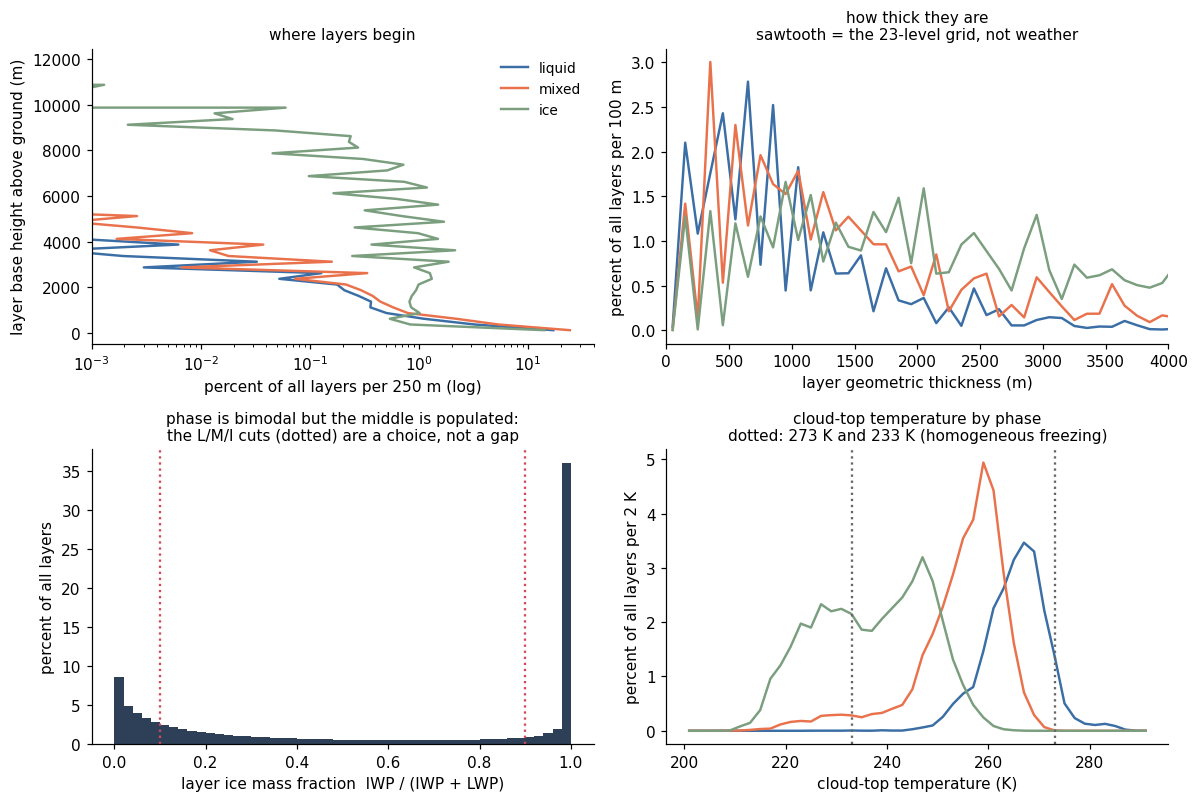

In [8]:
fig = ctd.fig_layer_properties(A, out_dir=SAVE_DIR)

tot = A.layer_phase_w[0].sum()
print("  phase of individual layers, area-weighted:")
for p in range(ctd.N_PHASE):
    print(f"    {ctd.PHASE_SYM[p]}  {ctd.PHASE_NAME[p]:<8} "
          f"{100*A.layer_phase_w[0, p]/tot:5.2f}%")

fb = 0.5*(ctd.FICE_BINS[:-1] + ctd.FICE_BINS[1:])
h = A.h_fice / A.h_fice.sum()
mid = (fb > LIQ_MAX) & (fb < ICE_MIN)
print(f"\n  fraction of layers in the 'mixed' interval: {100*h[mid].sum():.1f}%")
print(f"  fraction within 0.02 of pure liquid or pure ice: "
      f"{100*h[(fb < 0.02) | (fb > 0.98)].sum():.1f}%")


## Question 4 — so what ARE the common types?

First the question behind the question: **how few types cover most of the sky?**
A taxonomy needing 200 entries to reach 80% is not a taxonomy. The curve below
is the answer, at all four granularities at once.


  saved figures/cloud_types/cloud_types_coverage.png
number of distinct signatures needed to cover each share of cloudy hours:

 granularity  distinct  50%  80%  90%  95%  99%
     nlayers         5    1    2    2    2    3
       phase        62    2    4    5    7   12
phase+regime       374    3    7   12   18   43
        full      1669    5   14   26   49  151


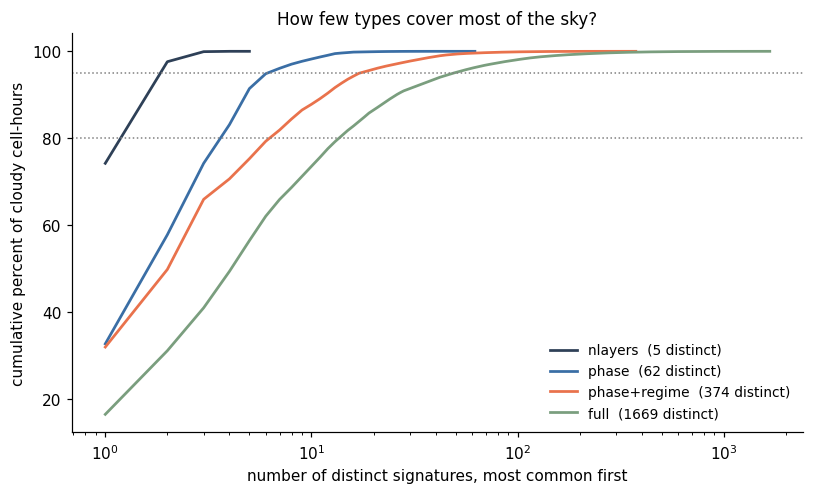

In [9]:
fig = ctd.fig_coverage(A, out_dir=SAVE_DIR)

rows = []
for g in ctd.GRANULARITIES:
    cov = ctd.coverage_curve(A.sig[g][0])
    rows.append({"granularity": g, "distinct": cov["distinct"],
                 **{f"{int(lv)}%": cov[lv] for lv in (50.0, 80.0, 90.0, 95.0, 99.0)}})
print("number of distinct signatures needed to cover each share of cloudy hours:\n")
print(pd.DataFrame(rows).to_string(index=False))


Now the types themselves, at the granularity that carries phase *and* altitude.
The `domain` bars are area-weighted over the whole 70-80°N strip; the
`Utqiagvik` bars are the single ERA5 cell holding the DOE ARM site, which is the
one to set beside ground-based statistics.


  saved figures/cloud_types/cloud_types_top_phase_regime.png


,signature,percent,cum_percent
0,BL:M,31.88,31.88
1,BL:I,17.88,49.76
2,BL:L,16.15,65.91
3,BL:L | MID:I,4.71,70.62
4,BL:M | MID:I,4.65,75.27
5,LOW:I,4.02,79.28
6,MID:I,2.58,81.87
7,BL:M | LOW:I,2.54,84.41
8,BL:L | HIGH:I,2.08,86.48
9,BL:M | HIGH:I,1.32,87.81


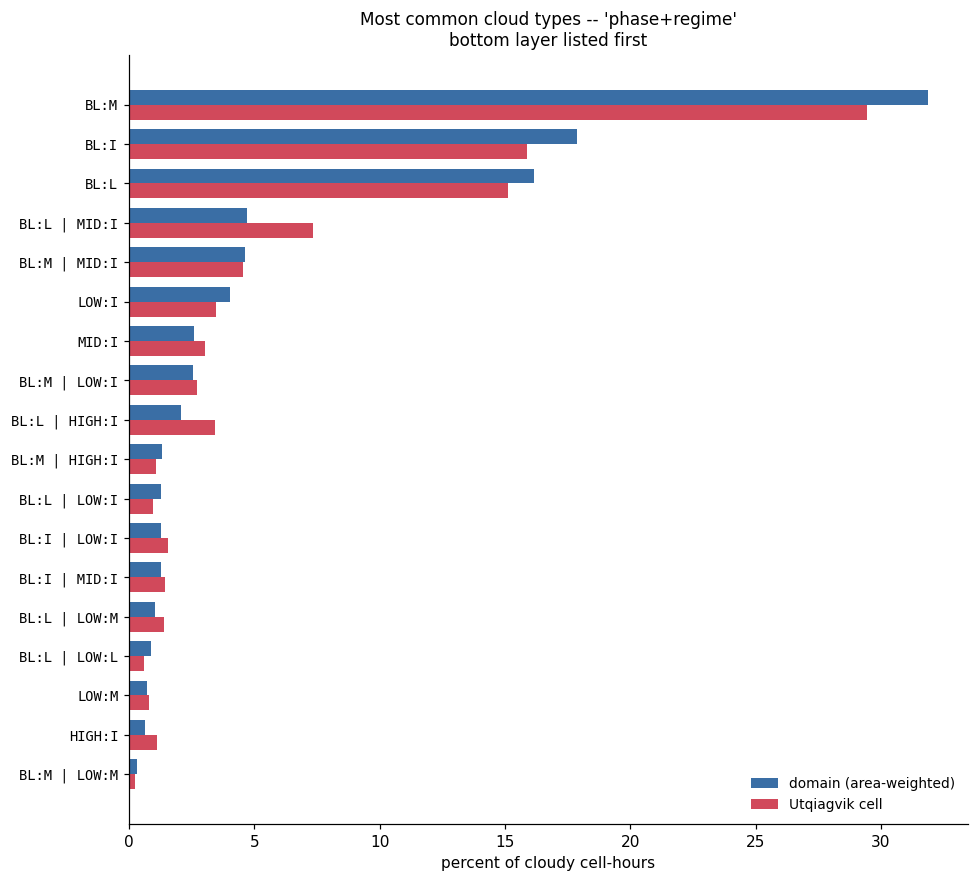

In [10]:
fig = ctd.fig_top_types(A, granularity="phase+regime", top=18, out_dir=SAVE_DIR)
ctd.counter_table(A.sig["phase+regime"][0], "phase+regime", top=12)[
    ["signature", "percent", "cum_percent"]].round(2)


And with the internal arrangement added -- the attribute that separates a
liquid-topped mixed-phase deck from a well-mixed one. This is where the Arctic
signal shows up.


  saved figures/cloud_types/cloud_types_top_full.png


,signature,percent,cum_percent
0,BL:M^L,16.39,16.39
1,BL:I,14.65,31.04
2,BL:M,9.88,40.92
3,BL:L^L,8.39,49.31
4,BL:L,7.09,56.40
5,BL:M^I,5.62,62.02
6,LOW:I,3.85,65.87
7,BL:M^L | MID:I,2.77,68.64
8,MID:I,2.57,71.21
9,BL:L^L | MID:I,2.29,73.50


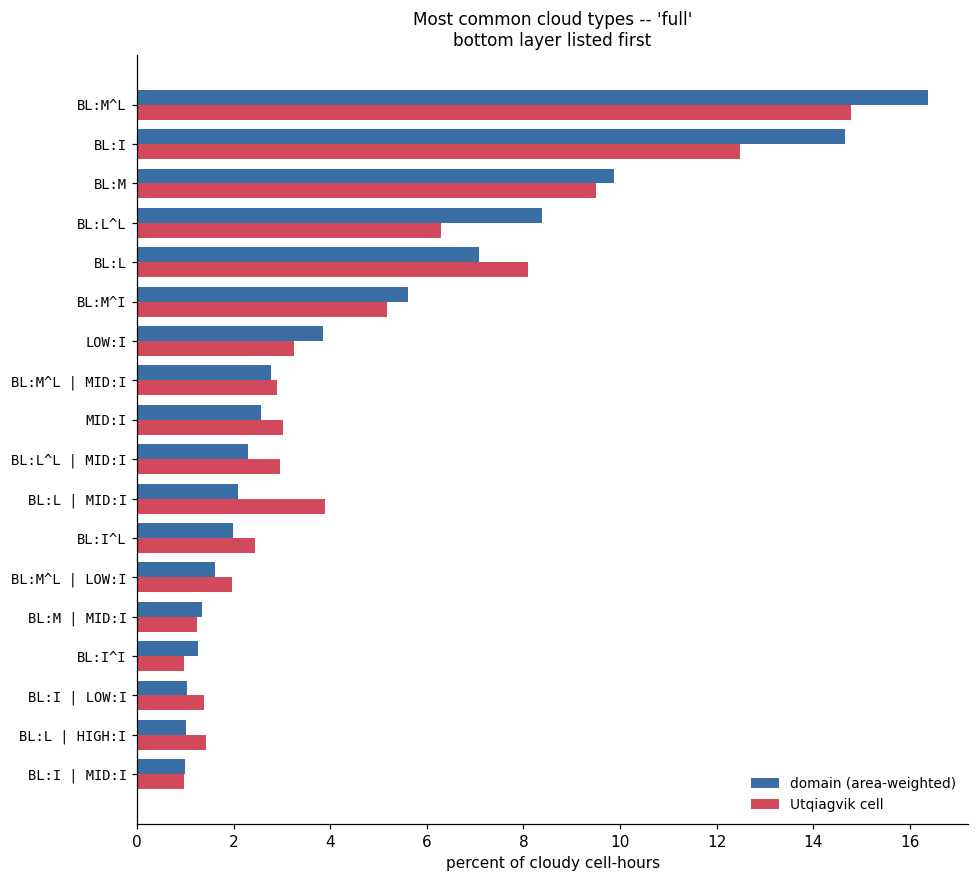

In [11]:
fig = ctd.fig_top_types(A, granularity="full", top=18, out_dir=SAVE_DIR)
ctd.counter_table(A.sig["full"][0], "full", top=12)[
    ["signature", "percent", "cum_percent"]].round(2)


Labels are cheap; the composite profiles below are what each label actually
looks like, averaged over every hour that carried it.


  saved figures/cloud_types/cloud_types_composites.png


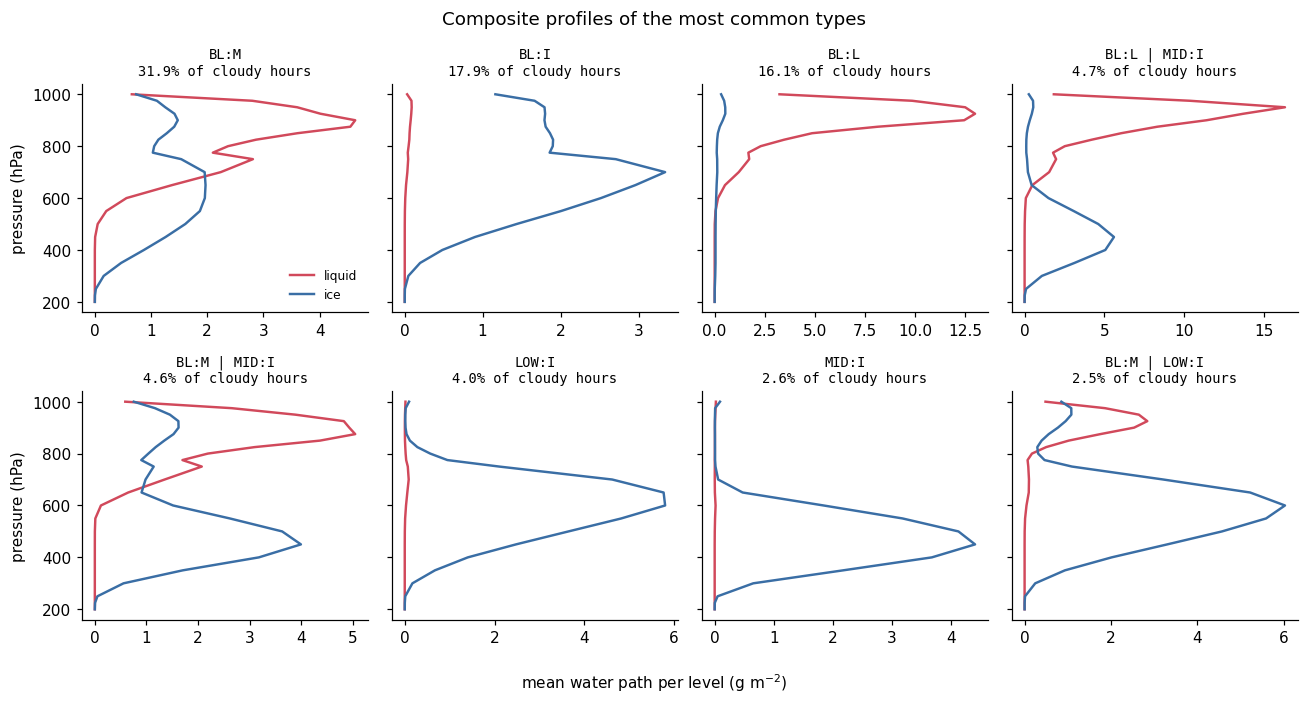

In [12]:
fig = ctd.fig_composite_profiles(A, granularity="phase+regime", top=8,
                                 out_dir=SAVE_DIR)


### Seasonal march

Eight months, Aug 2025 - Mar 2026: one full freeze-up and winter, from open water
through the return of the ice and out the far side. Still a single year, so read
it as one season's trajectory, not a climatology.

This is where the winter signal lives. Over Aug-Dec alone `BL:L` was the second
most common type at 24%; adding Jan-Mar drops it to 16% and lifts **`BL:I` from
5% to 18%**, into second place overall. The boundary-layer cloud does not go away
in deep winter -- it glaciates.


  saved figures/cloud_types/cloud_types_monthly.png


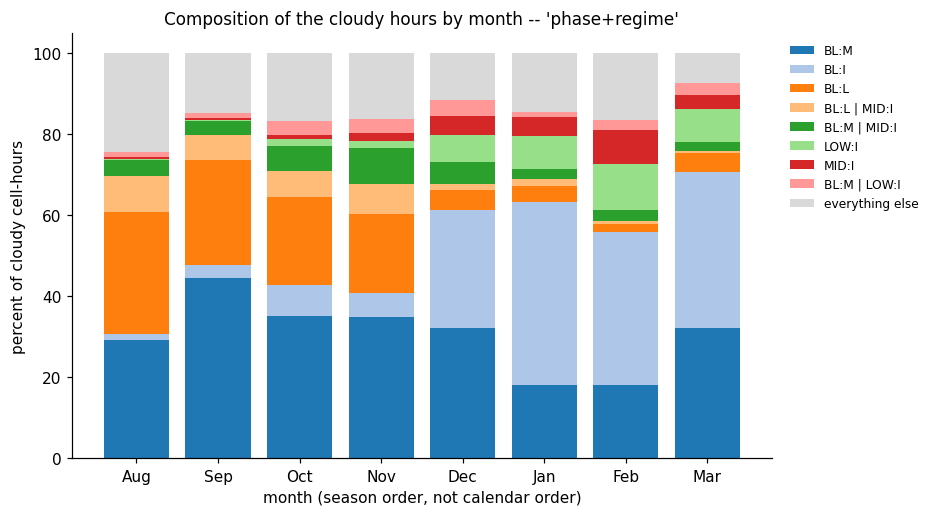

In [13]:
fig = ctd.fig_monthly(A, granularity="phase+regime", top=8, out_dir=SAVE_DIR)


## The cross-check: does the alphabet find real modes, or impose them?

A symbolic scheme can only find structure its alphabet can express. So the pass
also kept a stratified sample of **raw** LWP/IWP profiles, binned onto a common
height grid. Running k-means over those and cross-tabulating against the
signatures asks whether the symbolic types are modes of the data or artefacts of
the thresholds.

Neither inertia nor silhouette picks $k$ for you, and a clean $k$ would not be
evidence the clusters are physical. Look at what actually comes out.


  saved figures/cloud_types/cloud_types_cluster_sweep.png
  k =  4   inertia  107,354,281   silhouette 0.253
  k =  6   inertia   89,853,196   silhouette 0.199
  k =  8   inertia   80,095,559   silhouette 0.199
  k = 10   inertia   74,038,653   silhouette 0.186
  k = 12   inertia   69,259,833   silhouette 0.190


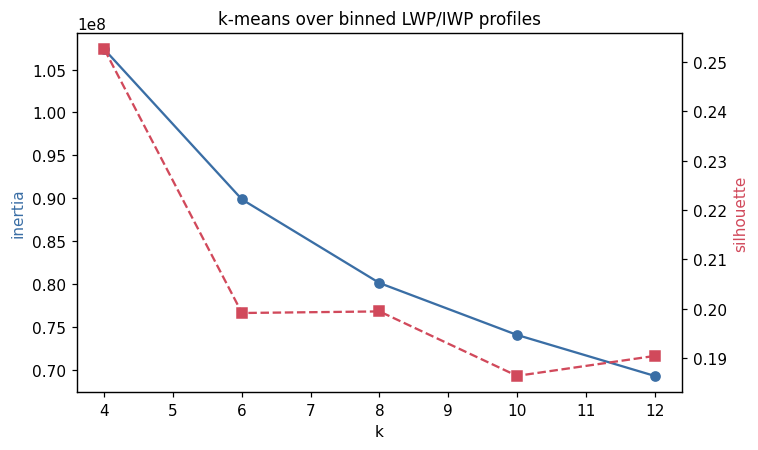

In [14]:
cl = ctd.cluster_profiles(A.sample, k_values=(4, 6, 8, 10, 12))
fig = ctd.fig_cluster_sweep(cl, out_dir=SAVE_DIR)
for k, inertia, sil in zip(cl["k"], cl["inertia"], cl["silhouette"]):
    print(f"  k = {k:2d}   inertia {inertia:12,.0f}   silhouette {sil:.3f}")


  saved figures/cloud_types/cloud_types_cluster_centers_k8.png
  saved figures/cloud_types/cloud_types_cluster_crosstab.png


,BL:M,BL:I,BL:L,BL:L | MID:I,BL:M | MID:I,LOW:I,MID:I,BL:M | LOW:I,BL:L | HIGH:I,BL:M | HIGH:I,other
cluster 0,17.0,67.0,0.0,0.0,0.0,5.0,0.0,2.0,0.0,0.0,7.0
cluster 1,42.0,3.0,3.0,9.0,7.0,1.0,0.0,1.0,3.0,6.0,26.0
cluster 2,58.0,1.0,17.0,2.0,5.0,0.0,0.0,1.0,2.0,2.0,12.0
cluster 3,42.0,18.0,33.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,3.0
cluster 4,10.0,34.0,0.0,1.0,4.0,19.0,5.0,9.0,0.0,0.0,18.0
cluster 5,54.0,2.0,35.0,1.0,1.0,0.0,0.0,0.0,1.0,1.0,5.0
cluster 6,2.0,0.0,4.0,29.0,15.0,0.0,14.0,0.0,12.0,4.0,20.0
cluster 7,11.0,21.0,0.0,5.0,13.0,12.0,3.0,11.0,0.0,1.0,25.0


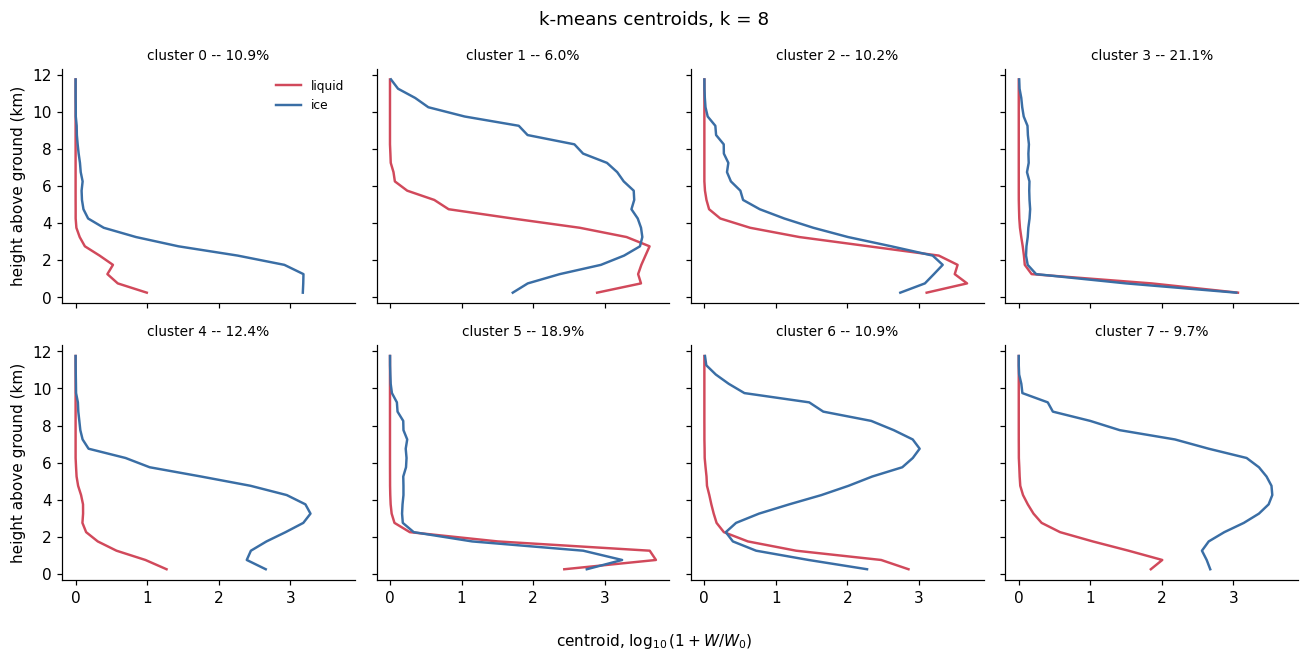

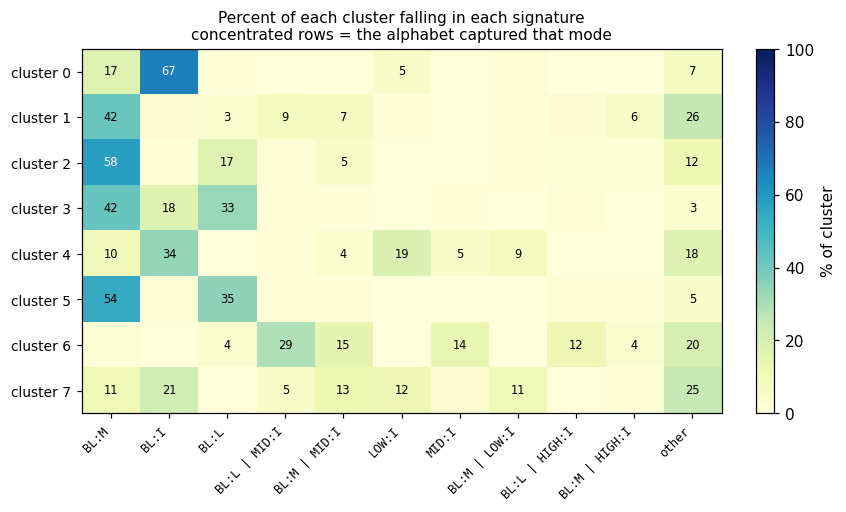

In [15]:
K = 8
fig = ctd.fig_cluster_centers(cl, K, A.sample, out_dir=SAVE_DIR)
tab = ctd.cluster_signature_crosstab(A.sample, cl["labels"][K], top=10)
fig = ctd.fig_cluster_crosstab(tab, out_dir=SAVE_DIR)
tab.round(0)


### What that comparison actually says

Two findings, and the second is more useful than the first.

**Silhouette is low (~0.17-0.23) and falls as $k$ rises.** There is no clean
natural $k$. The profile space is a **continuum**, not a set of well-separated
blobs. So any discrete taxonomy over these profiles -- this one, Rachel's A-F,
or anyone else's -- is a convenience for talking about the data, not a discovery
of natural kinds. That is worth knowing before quoting "the six Arctic cloud
types" to anybody.

**The clusters and the signatures cut along different axes.** Several clusters
mix `BL:M` and `BL:L` in varying proportions rather than mapping one-to-one onto
signatures. k-means, working on log water path, mostly splits the dominant
boundary-layer population by **how much water is in it**; the symbolic scheme
splits it by **phase**. Neither is wrong, and the disagreement is the
information: *condensate amount is a comparably large axis of variation to
phase, and the signature alphabet throws it away*.

If cloud amount matters for what you are doing -- and for a surface energy
budget it certainly does -- that argues for carrying LWP as a continuous
covariate alongside the type label rather than folding it into more symbols.


## Sensitivity: which parameters are reporting the atmosphere, and which are reporting me?

Each row below is a full re-run with one parameter changed. If the top types
reorder under a threshold, the taxonomy is reporting the threshold.

Restricted to the first 6 files so it finishes in about a minute, so the
absolute percentages differ from the full-archive numbers above -- it is the
*relative* movement that is being tested. A blank cell means that signature fell
out of **that run's** top 6, which is itself the signal worth watching.


In [16]:
base = ctd.parse_args(["--region", REGION, "--storage", STORAGE,
                       "--sample-per-file", "0"])
sens = ctd.sensitivity(
    base,
    {"min_gap_m":         [0.0, 500.0, 1000.0],
     "content_threshold": [1e-3, 1e-2, 5e-2],
     "min_layer_path":    [0.1, 1.0, 5.0],
     "content_basis":     ["gridmean", "incloud"],
     "stride":            [1, 4]},
    max_files=6, top=6)

sens.pivot_table(index="signature", columns=["parameter", "value"],
                 values="percent").round(1)


    min_gap_m = 0.0


    min_gap_m = 500.0


    min_gap_m = 1000.0


    content_threshold = 0.001


    content_threshold = 0.01


...

    content_basis = gridmean


    content_basis = incloud


    stride = 1


    stride = 4


parameter     content_basis         content_threshold             min_gap_m              min_layer_path             stride      
value              gridmean incloud             0.001  0.01  0.05       0.0 1000.0 500.0            0.1   1.0   5.0      1     4
signature                                                                                                                       
BL:L                   34.7    33.8              34.7  45.8  60.3      26.4   39.8  34.7           33.1  34.7  44.8   34.7  34.1
BL:L | HIGH:I           8.3     8.4               8.3   NaN   NaN       7.4    9.0   8.3            8.2   8.3   4.5    8.3   8.4
BL:L | LOW:L            5.9     5.2               5.9  12.0  10.0       9.8    2.2   5.9            7.0   5.9   4.5    5.9   5.8
BL:L | LOW:M            4.3     4.3               4.3   3.6   NaN       5.3    2.7   4.3            4.6   4.3   3.9    4.3   4.4
BL:L | MID:I            9.5    10.9               9.5   4.9   NaN       7.4   10.8   9.5            9.3   9.5   9.3    9.5   9.1
BL:L | MID:M            NaN     NaN               NaN   NaN   1.3       NaN    NaN   NaN            NaN   NaN   NaN    NaN   NaN
BL:M                   14.1    15.2              14.1   8.5   1.8      11.7   18.5  14.1           13.8  14.1  15.9   14.1  14.6
LOW:L                   NaN     NaN               NaN   6.0  15.8       NaN    NaN   NaN            NaN   NaN   NaN    NaN   NaN
LOW:M                   NaN     NaN               NaN   NaN   4.2       NaN    NaN   NaN            NaN   NaN   NaN    NaN   NaN

### Reading the sweep

- **`content_threshold` is the parameter that matters.** Raising it from
  $10^{-3}$ to $5\times10^{-2}$ g m$^{-3}$ roughly doubles the `BL:L` share and
  nearly erases `BL:M`, and lifts the apparent cloud base out of the `BL` band
  altogether so `LOW:*` types appear. It is not a detail; it is the definition
  of cloud. Quote it with every number.
- **`min_gap_m` sets the layer count**, as it must -- it is the only thing
  standing between one physical deck and two.
- **`content_basis` barely moves anything** (~1 percentage point). Reassuring:
  the grid-mean/in-cloud distinction, which matters enormously for comparing an
  ERA5 water path against an instrument, does not change which *structure* is
  identified.
- **`stride` barely moves anything either**, which says the ranking is not an
  artefact of counting correlated neighbouring cells -- though it says nothing
  about the *uncertainty*, which is far wider than the cell-hour count suggests.

## Caveats, collected

1. **Vertical resolution sets the layer count.** Counts are a lower bound,
   tighter aloft than near the ground.
2. **`BL` is a height band**, not a diagnosed boundary layer.
3. **`TP+` is truncated at 200 hPa** and is a lower bound. ERA5 does not
   represent polar stratospheric clouds.
4. **Contents are grid-box means**, already diluted by cloud fraction.
5. **Neighbouring cells are not independent.** The effective sample size is far
   below the cell-hour count, so *differences* between similar percentages are
   not significant on this evidence.
6. **One year.** Aug 2025 - Mar 2026 is a full freeze-up and winter, but a
   single realisation of it. Nothing here separates this year from the mean.

## Where this could go next

- **Break the types out by surface class** (open ocean / marginal ice / pack ice
  / land), the way `plot_cloud_cases_by_surface.py` does for A-F. The pass
  already carries the machinery; it needs the `siconc` and land-sea-mask
  selectors wired into the accumulator.
- **Join to the surface energy budget.** Every signature here is keyed by time
  and cell, so `msdwlwrf` can be conditioned on cloud type directly -- which is
  the question the type taxonomy exists to serve.
- **Add more years.** One Aug-Mar season is on disk. The winter contrast is
  already the largest signal in the record, which makes interannual spread the
  obvious next thing to bound.
